# Battery-Aware Pathfinding in GridWorld using Q-Learning

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set random seed for reproducibility
np.random.seed(42)

## 1. GridWorld Environment Setup

We define the `GridWorld` class, which will encapsulate the environment logic, including the grid layout, battery mechanics, state representation, actions, and reward system.

In [2]:
class GridWorld:
    def __init__(self):
        self.grid_size = 5
        # S: Start, G: Goal, H: High-energy, R: Recharge, .: Normal
        self.grid = np.array([
            ['S', '.', '.', '.', '.'],
            ['.', 'H', '.', 'R', '.'],
            ['.', '.', 'H', '.', '.'],
            ['.', 'R', '.', '.', 'H'],
            ['.', '.', '.', 'G', '.']
        ])

        self.start_pos = (0, 0)
        self.goal_pos = (4, 3)
        self.initial_battery = 20

        self.actions = {'up': 0, 'down': 1, 'left': 2, 'right': 3}
        self.action_map = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)} # dx, dy

        self.current_pos = self.start_pos
        self.current_battery = self.initial_battery

        # Reward system
        self.rewards = {
            'normal_move': -1,
            'high_energy_cell': -3,
            'recharge_cell': +5,
            'goal_reached': +20,
            'battery_empty': -20
        }

    def reset(self):
        self.current_pos = self.start_pos
        self.current_battery = self.initial_battery
        return self.current_pos[0], self.current_pos[1], self.current_battery

    def step(self, action):
        # Get current state before action
        old_x, old_y = self.current_pos

        # Deduct 1 battery for any move
        self.current_battery -= 1
        reward = self.rewards['normal_move']

        # Check for battery depletion before moving
        if self.current_battery <= 0:
            return (old_x, old_y, self.current_battery), self.rewards['battery_empty'], True, {}

        # Calculate next position for agent
        dx, dy = self.action_map[action]
        new_x, new_y = old_x + dx, old_y + dy

        # Check for out-of-bounds for agent
        if not (0 <= new_x < self.grid_size and 0 <= new_y < self.grid_size):
            # Stay in the same position if out of bounds, but still consume battery
            new_x, new_y = old_x, old_y

        self.current_pos = (new_x, new_y)
        cell_type = self.grid[new_x, new_y]

        # Apply cell-specific effects for agent's new position
        if cell_type == 'H':
            self.current_battery -= 3  # Additional cost for high-energy cell
            reward += self.rewards['high_energy_cell'] # Add specific reward contribution
        elif cell_type == 'R':
            self.current_battery += 5  # Gain battery from recharge cell
            reward += self.rewards['recharge_cell'] # Add specific reward contribution

        # Ensure battery doesn't exceed initial capacity
        self.current_battery = min(self.current_battery, self.initial_battery)

        # Check terminal conditions
        done = False
        if self.current_battery <= 0: # Battery ran out
            reward = self.rewards['battery_empty']
            done = True
        elif self.current_pos == self.goal_pos: # Reached goal
            reward = self.rewards['goal_reached']
            done = True

        return (self.current_pos[0], self.current_pos[1], self.current_battery), reward, done, {}

    def get_state_space_size(self):
        # x, y, battery_level (0 to initial_battery)
        return self.grid_size, self.grid_size, self.initial_battery + 1

    def get_action_space_size(self):
        return len(self.actions)

## 2. Q-Learning Agent Implementation

We will now implement the Q-Learning agent. This includes initializing the Q-table, defining how the agent chooses actions (epsilon-greedy policy), and implementing the learning rule to update Q-values.

In [3]:
class QLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay_rate=0.001):
        self.env = env
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon_start # Exploration-exploitation trade-off parameter
        self.epsilon_end = epsilon_end
        self.epsilon_decay_rate = epsilon_decay_rate

        # Initialize Q-table with zeros
        grid_x, grid_y, battery_levels = env.get_state_space_size()
        action_space_size = env.get_action_space_size()
        # Q-table dimensions: (grid_x, grid_y, battery_level, action)
        self.q_table = np.zeros((grid_x, grid_y, battery_levels, action_space_size))

    def choose_action(self, state):
        x, y, battery = state
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.env.get_action_space_size())  # Explore
        else:
            return np.argmax(self.q_table[x, y, battery])  # Exploit

    def learn(self, state, action, reward, next_state):
        x, y, battery = state
        next_x, next_y, next_battery = next_state

        # Ensure next_battery is within valid range for Q-table indexing
        # If battery becomes negative, treat it as 0 for Q-table lookup purpose, as it's a terminal state.
        next_battery_idx = max(0, min(next_battery, self.env.initial_battery))

        # Q-learning formula
        old_value = self.q_table[x, y, battery, action]
        next_max = np.max(self.q_table[next_x, next_y, next_battery_idx])

        new_value = old_value + self.alpha * (reward + self.gamma * next_max - old_value)
        self.q_table[x, y, battery, action] = new_value

    def decay_epsilon(self, episode):
        self.epsilon = self.epsilon_end + (self.epsilon - self.epsilon_end) * np.exp(-self.epsilon_decay_rate * episode)

In [4]:
# Re-initialize environment and agent to ensure all latest changes are applied
env = GridWorld()
agent = QLearningAgent(env)

# Training parameters
n_episodes = 2000
max_steps_per_episode = 100

# To store results
episode_rewards = []

print("Starting Q-Learning training with updated environment...")

for episode in range(n_episodes):
    state = env.reset() # (x, y, battery_level)
    done = False
    total_reward = 0
    steps_in_episode = 0

    while not done and steps_in_episode < max_steps_per_episode:
        action = agent.choose_action(state)
        next_state, reward, done, _ = env.step(action)

        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward
        steps_in_episode += 1

    agent.decay_epsilon(episode) # Decay epsilon after each episode
    episode_rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}/{n_episodes}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.4f}")

print("\nTraining complete!")

Starting Q-Learning training with updated environment...
Episode 100/2000, Total Reward: 140, Epsilon: 0.0170
Episode 200/2000, Total Reward: 145, Epsilon: 0.0100
Episode 300/2000, Total Reward: 140, Epsilon: 0.0100
Episode 400/2000, Total Reward: 140, Epsilon: 0.0100
Episode 500/2000, Total Reward: 140, Epsilon: 0.0100
Episode 600/2000, Total Reward: 135, Epsilon: 0.0100
Episode 700/2000, Total Reward: 145, Epsilon: 0.0100
Episode 800/2000, Total Reward: 145, Epsilon: 0.0100
Episode 900/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1000/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1100/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1200/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1300/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1400/2000, Total Reward: 140, Epsilon: 0.0100
Episode 1500/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1600/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1700/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1800/2000, Total Reward: 1

In [5]:
# Re-initialize environment and agent for extended training
env = GridWorld()
agent = QLearningAgent(env)

# Training parameters - increased episodes
n_episodes = 5000  # Increased from 2000
max_steps_per_episode = 100

# To store results
episode_rewards = []

print("Starting Q-Learning training with extended episodes...")

for episode in range(n_episodes):
    state = env.reset() # (x, y, battery_level)
    done = False
    total_reward = 0
    steps_in_episode = 0

    while not done and steps_in_episode < max_steps_per_episode:
        action = agent.choose_action(state)
        next_state, reward, done, _ = env.step(action)

        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward
        steps_in_episode += 1

    agent.decay_epsilon(episode) # Decay epsilon after each episode
    episode_rewards.append(total_reward)

    if (episode + 1) % 500 == 0: # Print less frequently for more episodes
        print(f"Episode {episode + 1}/{n_episodes}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.4f}")

print("\nExtended training complete!")

Starting Q-Learning training with extended episodes...
Episode 500/5000, Total Reward: 19, Epsilon: 0.0100
Episode 1000/5000, Total Reward: 19, Epsilon: 0.0100
Episode 1500/5000, Total Reward: 19, Epsilon: 0.0100
Episode 2000/5000, Total Reward: 19, Epsilon: 0.0100
Episode 2500/5000, Total Reward: 19, Epsilon: 0.0100
Episode 3000/5000, Total Reward: 19, Epsilon: 0.0100
Episode 3500/5000, Total Reward: 22, Epsilon: 0.0100
Episode 4000/5000, Total Reward: 19, Epsilon: 0.0100
Episode 4500/5000, Total Reward: 19, Epsilon: 0.0100
Episode 5000/5000, Total Reward: 19, Epsilon: 0.0100

Extended training complete!


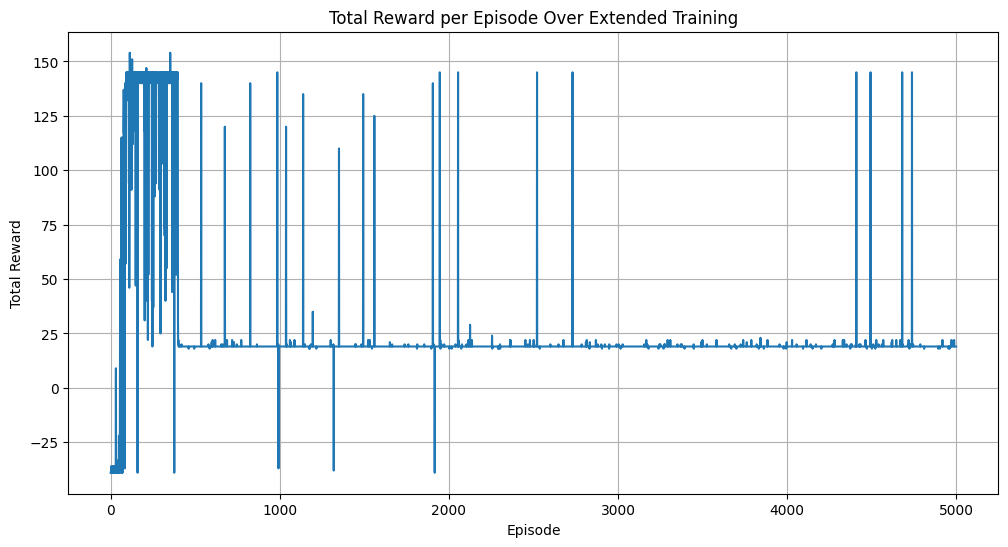


Optimal Path Visualization (S: Start, G: Goal, H: High-Energy, R: Recharge):
S . . . .
* H . R .
* . H . .
* * . . H
. * * G .


In [6]:
# Plot rewards per episode after extended training
plt.figure(figsize=(12, 6))
plt.plot(episode_rewards)
plt.title('Total Reward per Episode Over Extended Training')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

# Visualize the optimal path after extended training
def plot_optimal_path(env, agent):
    current_env = GridWorld() # Create a fresh environment for path visualization
    state = current_env.reset()
    path = [current_env.current_pos]
    done = False

    # Temporarily set epsilon to 0 for exploitation only
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    step_count = 0
    while not done and step_count < 2 * env.grid_size * env.grid_size: # Limit steps to prevent infinite loops
        x, y, battery = state
        action = agent.choose_action(state) # Choose action greedily

        dx, dy = env.action_map[action]
        next_x, next_y = x + dx, y + dy

        if not (0 <= next_x < env.grid_size and 0 <= next_y < env.grid_size):
            next_x, next_y = x, y # Agent stays if hits wall

        current_state_for_env_step = (current_env.current_pos[0], current_env.current_pos[1], current_env.current_battery)
        next_state_info, reward, done, _ = current_env.step(action)
        state = next_state_info # Update state for next iteration
        path.append(current_env.current_pos) # Add new position to path
        step_count += 1

        if current_env.current_battery <= 0 and not done: # If battery runs out, path ends here
            done = True

    print("\nOptimal Path Visualization (S: Start, G: Goal, H: High-Energy, R: Recharge):")
    path_grid = np.copy(env.grid).astype(str)

    for i, (r, c) in enumerate(path):
        if path_grid[r, c] not in ['S', 'G']:
            path_grid[r, c] = '*' # Mark path

    path_grid[env.start_pos] = 'S'
    path_grid[env.goal_pos] = 'G'

    for row in path_grid:
        print(' '.join(row))

    agent.epsilon = original_epsilon

plot_optimal_path(env, agent)

In [7]:
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.patches as mpatches

def create_animation(env_original, agent, frames_per_second=1):
    current_env = GridWorld() # Create a fresh environment for simulation
    state = current_env.reset() # (x, y, battery_level)
    path_history = [(current_env.current_pos, current_env.current_battery)]
    done = False

    original_epsilon = agent.epsilon
    agent.epsilon = 0

    step_count = 0
    max_animation_steps = 2 * env_original.grid_size * env_original.grid_size * env_original.initial_battery

    while not done and step_count < max_animation_steps:
        x, y, battery = state
        action = agent.choose_action(state)

        next_state, reward, done, _ = current_env.step(action)
        state = next_state
        path_history.append((current_env.current_pos, current_env.current_battery))
        step_count += 1

        if current_env.current_battery <= 0 and not done:
            done = True
            if path_history[-1][1] > 0:
                path_history.append((current_env.current_pos, 0))

    agent.epsilon = original_epsilon

    fig, ax = plt.subplots(figsize=(env_original.grid_size, env_original.grid_size))
    ax.set_xticks(np.arange(-0.5, env_original.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env_original.grid_size, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.set_xlim(-0.5, env_original.grid_size - 0.5)
    ax.set_ylim(env_original.grid_size - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])

    cell_colors = {
        'S': 'lightgreen',
        'G': 'salmon',
        'H': 'lightcoral',
        'R': 'lightblue',
        '.': 'lightgray'
    }

    for r in range(env_original.grid_size):
        for c in range(env_original.grid_size):
            cell_type = env_original.grid[r, c]
            color = cell_colors.get(cell_type, 'lightgray')
            rect = mpatches.Rectangle([c - 0.5, r - 0.5], 1, 1, facecolor=color, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

            if cell_type == 'S':
                ax.text(c, r, 'S', ha='center', va='center', color='darkgreen', fontsize=12, weight='bold')
            elif cell_type == 'G':
                ax.text(c, r, 'G', ha='center', va='center', color='darkred', fontsize=12, weight='bold')
            elif cell_type == 'H':
                ax.text(c, r, 'H', ha='center', va='center', color='darkred', fontsize=12, weight='bold')
            elif cell_type == 'R':
                ax.text(c, r, 'R', ha='center', va='center', color='darkblue', fontsize=12, weight='bold')

    ax.set_title('Battery-Aware Pathfinding in GridWorld (Extended Training)', fontsize=16)

    legend_patches = [
        mpatches.Patch(color=cell_colors['S'], label='Start (S)'),
        mpatches.Patch(color=cell_colors['G'], label='Goal (G)'),
        mpatches.Patch(color=cell_colors['H'], label='High-Energy (H)'),
        mpatches.Patch(color=cell_colors['R'], label='Recharge (R)'),
        mpatches.Patch(color=cell_colors['.'], label='Normal (.)')
    ]
    legend = ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    agent_marker, = ax.plot([], [], 'o', color='gold', markersize=20, markeredgecolor='black', zorder=5)
    battery_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, ha='left', va='top', fontsize=12,
                           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    def init():
        agent_marker.set_data([], [])
        battery_text.set_text('')
        return agent_marker, battery_text, legend

    def update(frame):
        (r, c), battery = path_history[frame]
        agent_marker.set_data([c], [r])
        battery_text.set_text(f'Battery: {battery}')
        return agent_marker, battery_text, legend

    ani = animation.FuncAnimation(
        fig, update, frames=len(path_history),
        init_func=init, blit=True, repeat=False, interval=1000 / frames_per_second
    )

    gif_path = 'gridworld_path_animation_extended.gif'
    ani.save(gif_path, writer='pillow', fps=frames_per_second)
    plt.close(fig)

    print(f"Animation saved as {gif_path}")
    return HTML(f'<img src="{gif_path}">')

# Generate and display the animation
animation_output = create_animation(env, agent)
display(animation_output)

Animation saved as gridworld_path_animation_extended.gif


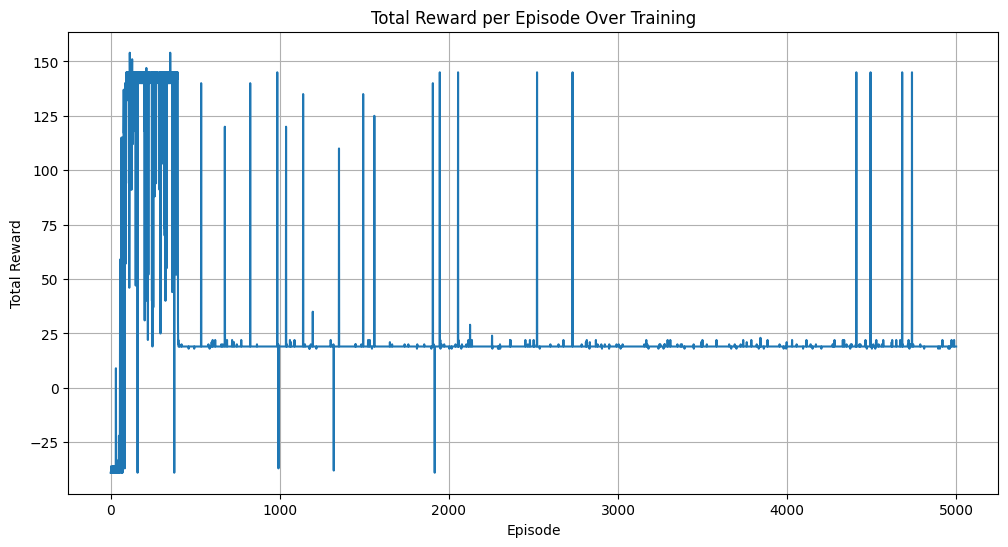


Optimal Path Visualization (S: Start, G: Goal, H: High-Energy, R: Recharge, X: Hazard Collision):
S . . . .
* H . R .
* . H . .
* * . . H
. * * G .


In [8]:
# Plot rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(episode_rewards)
plt.title('Total Reward per Episode Over Training')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

# Visualize the optimal path
def plot_optimal_path(env, agent):
    current_env = GridWorld() # Create a fresh environment for path visualization
    state = current_env.reset()
    path = [current_env.current_pos]
    done = False

    # Temporarily set epsilon to 0 for exploitation only
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    # Create a grid for visualization
    display_grid = np.copy(env.grid).astype(str)
    display_grid[current_env.start_pos] = 'S'
    display_grid[current_env.goal_pos] = 'G'

    step_count = 0
    while not done and step_count < 2 * env.grid_size * env.grid_size: # Limit steps to prevent infinite loops
        x, y, battery = state
        action = agent.choose_action(state) # Choose action greedily

        # Manually apply action to get next position for path visualization
        dx, dy = env.action_map[action]
        next_x, next_y = x + dx, y + dy

        # Handle boundary conditions for visualization only
        if not (0 <= next_x < env.grid_size and 0 <= next_y < env.grid_size):
            next_x, next_y = x, y # Agent stays if hits wall

        # Simulate step without modifying the actual environment state (as env is reset below)
        # This is for path plotting logic only. The actual step() call determines rewards/done.

        # Correct way to get next_state for path following
        current_state_for_env_step = (current_env.current_pos[0], current_env.current_pos[1], current_env.current_battery)
        next_state_info, reward, done, _ = current_env.step(action)
        state = next_state_info # Update state for next iteration
        path.append(current_env.current_pos) # Add new position to path
        step_count += 1

        if current_env.current_battery <= 0 and not done: # If battery runs out, path ends here
            done = True

    print("\nOptimal Path Visualization (S: Start, G: Goal, H: High-Energy, R: Recharge, X: Hazard Collision):")

    path_grid = np.copy(env.grid).astype(str) # Start with the original grid content

    for i, (r, c) in enumerate(path):
        # Mark cells on the path, ensuring 'S' and 'G' are eventually at their correct positions
        if path_grid[r, c] not in ['S', 'G']:
            path_grid[r, c] = '*' # Mark path

    # Ensure S and G are at their correct places at the end of marking
    path_grid[env.start_pos] = 'S'
    path_grid[env.goal_pos] = 'G'

    # Print the grid with path
    for row in path_grid:
        print(' '.join(row))

    # Restore original epsilon
    agent.epsilon = original_epsilon

plot_optimal_path(env, agent)

In [9]:
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.patches as mpatches

def create_animation(env_original, agent, frames_per_second=1):
    current_env = GridWorld() # Create a fresh environment for simulation
    state = current_env.reset() # (x, y, battery_level)
    path_history = [(current_env.current_pos, current_env.current_battery)]
    done = False

    # Temporarily set epsilon to 0 for exploitation only
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    step_count = 0
    # Set a generous upper bound on steps to prevent infinite loops in cases where goal isn't reached
    max_animation_steps = 2 * env_original.grid_size * env_original.grid_size * env_original.initial_battery

    while not done and step_count < max_animation_steps:
        x, y, battery = state
        action = agent.choose_action(state) # Choose action greedily

        next_state, reward, done, _ = current_env.step(action)
        state = next_state
        path_history.append((current_env.current_pos, current_env.current_battery))
        step_count += 1

        # If battery runs out, the path simulation ends
        if current_env.current_battery <= 0 and not done:
            done = True
            # If the last recorded battery was not 0, record the final state with 0 battery
            if path_history[-1][1] > 0:
                path_history.append((current_env.current_pos, 0))

    agent.epsilon = original_epsilon # Restore original epsilon

    # Set up the plot for animation
    fig, ax = plt.subplots(figsize=(env_original.grid_size, env_original.grid_size))
    ax.set_xticks(np.arange(-0.5, env_original.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env_original.grid_size, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.set_xlim(-0.5, env_original.grid_size - 0.5)
    ax.set_ylim(env_original.grid_size - 0.5, -0.5) # Invert y-axis to match array indexing
    ax.set_aspect('equal')
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Cell colors
    cell_colors = {
        'S': 'lightgreen',
        'G': 'purple',
        'H': 'lightcoral',
        'R': 'lightblue',
        '.': 'lightgray'
    }

    # Draw the grid cells with colored rectangles and labels
    for r in range(env_original.grid_size):
        for c in range(env_original.grid_size):
            cell_type = env_original.grid[r, c]
            color = cell_colors.get(cell_type, 'lightgray')
            rect = mpatches.Rectangle([c - 0.5, r - 0.5], 1, 1, facecolor=color, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

            if cell_type == 'S':
                ax.text(c, r, 'S', ha='center', va='center', color='darkgreen', fontsize=12, weight='bold')
            elif cell_type == 'G':
                ax.text(c, r, 'G', ha='center', va='center', color='darkred', fontsize=12, weight='bold')
            elif cell_type == 'H':
                ax.text(c, r, 'H', ha='center', va='center', color='darkred', fontsize=12, weight='bold')
            elif cell_type == 'R':
                ax.text(c, r, 'R', ha='center', va='center', color='darkblue', fontsize=12, weight='bold')

    # Set title for the animation
    ax.set_title('Battery-Aware Pathfinding in GridWorld', fontsize=16)

    # Create legend handles
    legend_patches = [
        mpatches.Patch(color=cell_colors['S'], label='Start (S)'),
        mpatches.Patch(color=cell_colors['G'], label='Goal (G)'),
        mpatches.Patch(color=cell_colors['H'], label='High-Energy (H)'),
        mpatches.Patch(color=cell_colors['R'], label='Recharge (R)'),
        mpatches.Patch(color=cell_colors['.'], label='Normal (.)')
    ]
    legend = ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    # Agent marker and battery display
    agent_marker, = ax.plot([], [], 'o', color='gold', markersize=20, markeredgecolor='black', zorder=5)
    battery_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, ha='left', va='top', fontsize=12,
                           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    def init():
        agent_marker.set_data([], [])
        battery_text.set_text('')
        return agent_marker, battery_text, legend

    def update(frame):
        (r, c), battery = path_history[frame]
        agent_marker.set_data([c], [r]) # Fix: Pass c and r as sequences
        battery_text.set_text(f'Battery: {battery}')
        return agent_marker, battery_text, legend

    ani = animation.FuncAnimation(
        fig, update, frames=len(path_history),
        init_func=init, blit=True, repeat=False, interval=1000 / frames_per_second
    )

    gif_path = 'gridworld_path_animation.gif'
    ani.save(gif_path, writer='pillow', fps=frames_per_second)
    plt.close(fig) # Close the figure to prevent it from showing as a static plot

    print(f"Animation saved as {gif_path}")
    # Display the GIF directly in Colab
    return HTML(f'<img src="{gif_path}">')

# Generate and display the animation
animation_output = create_animation(env, agent)
display(animation_output)

Animation saved as gridworld_path_animation.gif


In [10]:
animation_output = create_animation(env, agent)
display(animation_output)

Animation saved as gridworld_path_animation.gif


## 3. Training the Q-Learning Agent

This section will set up the training parameters, run multiple episodes, and allow the agent to learn the optimal policy using the `learn` and `choose_action` methods. We will also track rewards per episode.

In [11]:
# Initialize environment and agent
env = GridWorld()
agent = QLearningAgent(env)

# Training parameters
n_episodes = 2000
max_steps_per_episode = 100

# To store results
episode_rewards = []

print("Starting Q-Learning training...")

for episode in range(n_episodes):
    state = env.reset() # (x, y, battery_level)
    done = False
    total_reward = 0
    steps_in_episode = 0

    while not done and steps_in_episode < max_steps_per_episode:
        action = agent.choose_action(state)
        next_state, reward, done, _ = env.step(action)

        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward
        steps_in_episode += 1

    agent.decay_epsilon(episode) # Decay epsilon after each episode
    episode_rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}/{n_episodes}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.4f}")

print("\nTraining complete!")

Starting Q-Learning training...
Episode 100/2000, Total Reward: 145, Epsilon: 0.0170
Episode 200/2000, Total Reward: 145, Epsilon: 0.0100
Episode 300/2000, Total Reward: 145, Epsilon: 0.0100
Episode 400/2000, Total Reward: 145, Epsilon: 0.0100
Episode 500/2000, Total Reward: 145, Epsilon: 0.0100
Episode 600/2000, Total Reward: 140, Epsilon: 0.0100
Episode 700/2000, Total Reward: 145, Epsilon: 0.0100
Episode 800/2000, Total Reward: 145, Epsilon: 0.0100
Episode 900/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1000/2000, Total Reward: 140, Epsilon: 0.0100
Episode 1100/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1200/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1300/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1400/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1500/2000, Total Reward: 145, Epsilon: 0.0100
Episode 1600/2000, Total Reward: 140, Epsilon: 0.0100
Episode 1700/2000, Total Reward: 140, Epsilon: 0.0100
Episode 1800/2000, Total Reward: 145, Epsilon: 0.0100
Episo

## 4. Results and Visualization

After training, we will visualize the agent's performance by plotting the total rewards per episode and demonstrating the optimal path learned by the agent on the grid.

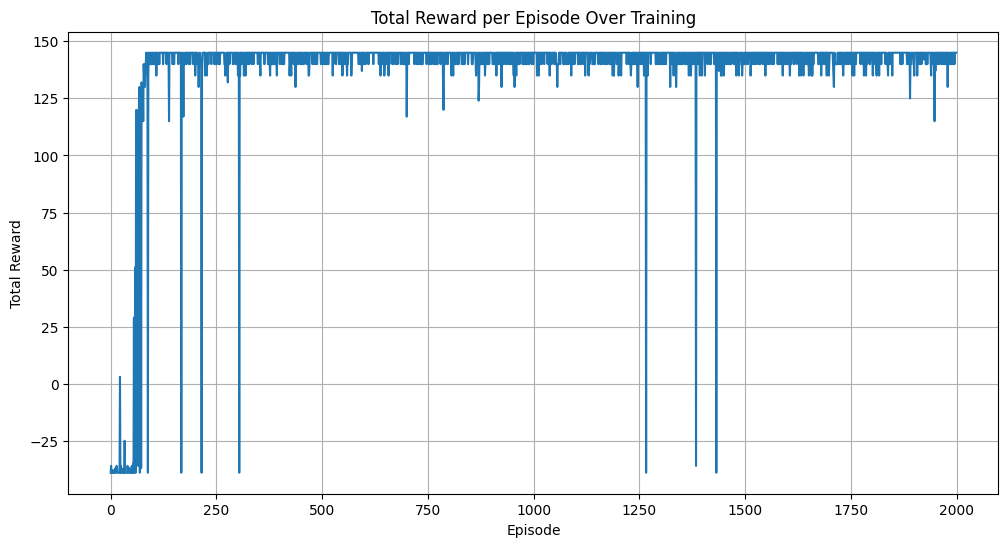


Optimal Path Visualization (S: Start, G: Goal, H: High-Energy, R: Recharge):
S * * * .
. H . R .
. . H . .
. R . . H
. . . G .


In [12]:
# Plot rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(episode_rewards)
plt.title('Total Reward per Episode Over Training')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

# Visualize the optimal path
def plot_optimal_path(env, agent):
    current_env = GridWorld() # Create a fresh environment for path visualization
    state = current_env.reset()
    path = [current_env.current_pos]
    done = False

    # Temporarily set epsilon to 0 for exploitation only
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    # Create a grid for visualization
    display_grid = np.copy(env.grid).astype(str)
    display_grid[current_env.start_pos] = 'S'
    display_grid[current_env.goal_pos] = 'G'

    step_count = 0
    while not done and step_count < 2 * env.grid_size * env.grid_size: # Limit steps to prevent infinite loops
        x, y, battery = state
        action = agent.choose_action(state) # Choose action greedily

        # Manually apply action to get next position for path visualization
        dx, dy = env.action_map[action]
        next_x, next_y = x + dx, y + dy

        # Handle boundary conditions for visualization only
        if not (0 <= next_x < env.grid_size and 0 <= next_y < env.grid_size):
            next_x, next_y = x, y # Agent stays if hits wall

        # Simulate step without modifying the actual environment state (as env is reset below)
        # This is for path plotting logic only. The actual step() call determines rewards/done.

        # Need to use the environment's step method to get the correct next_state and done status
        # But since we are visualizing, we want to see the effect of the chosen greedy action
        # So, we'll manually update position and battery for display, then use env.step for actual state transition

        # Correct way to get next_state for path following
        current_state_for_env_step = (current_env.current_pos[0], current_env.current_pos[1], current_env.current_battery)
        next_state_info, reward, done, _ = current_env.step(action)
        state = next_state_info # Update state for next iteration
        path.append(current_env.current_pos) # Add new position to path
        step_count += 1

        if current_env.current_battery <= 0 and not done: # If battery runs out, path ends here
            done = True

    print("\nOptimal Path Visualization (S: Start, G: Goal, H: High-Energy, R: Recharge):")
    path_coords = set(path)

    path_grid = np.full(env.grid.shape, '.', dtype=str)
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            path_grid[r, c] = env.grid[r, c]

    for i, (r, c) in enumerate(path):
        if (r, c) == env.start_pos:
            path_grid[r, c] = 'S'
        elif (r, c) == env.goal_pos:
            path_grid[r, c] = 'G'
        elif path_grid[r, c] == '.': # Only mark normal cells as path
            path_grid[r, c] = '*' # Mark path

    # Print the grid with path
    for row in path_grid:
        print(' '.join(row))

    # Restore original epsilon
    agent.epsilon = original_epsilon

plot_optimal_path(env, agent)

In [13]:
import matplotlib.animation as animation
from IPython.display import HTML

def create_animation(env_original, agent, frames_per_second=1):
    current_env = GridWorld() # Create a fresh environment for simulation
    state = current_env.reset() # (x, y, battery_level)
    path_history = [(current_env.current_pos, current_env.current_battery)]
    done = False

    # Temporarily set epsilon to 0 for exploitation only
    original_epsilon = agent.epsilon
    agent.epsilon = 0

    step_count = 0
    # Set a generous upper bound on steps to prevent infinite loops in cases where goal isn't reached
    max_animation_steps = 2 * env_original.grid_size * env_original.grid_size * env_original.initial_battery

    while not done and step_count < max_animation_steps:
        x, y, battery = state
        action = agent.choose_action(state) # Choose action greedily

        next_state, reward, done, _ = current_env.step(action)
        state = next_state
        path_history.append((current_env.current_pos, current_env.current_battery))
        step_count += 1

        # If battery runs out, the path simulation ends
        if current_env.current_battery <= 0 and not done:
            done = True
            # If the last recorded battery was not 0, record the final state with 0 battery
            if path_history[-1][1] > 0:
                path_history.append((current_env.current_pos, 0))

    agent.epsilon = original_epsilon # Restore original epsilon

    # Set up the plot for animation
    fig, ax = plt.subplots(figsize=(env_original.grid_size, env_original.grid_size))
    ax.set_xticks(np.arange(-0.5, env_original.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env_original.grid_size, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.set_xlim(-0.5, env_original.grid_size - 0.5)
    ax.set_ylim(env_original.grid_size - 0.5, -0.5) # Invert y-axis to match array indexing
    ax.set_aspect('equal')
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Draw the grid cells with labels
    for r in range(env_original.grid_size):
        for c in range(env_original.grid_size):
            cell_type = env_original.grid[r, c]
            if cell_type == 'S':
                ax.text(c, r, 'S', ha='center', va='center', color='green', fontsize=12, weight='bold')
            elif cell_type == 'G':
                ax.text(c, r, 'G', ha='center', va='center', color='red', fontsize=12, weight='bold')
            elif cell_type == 'H':
                ax.text(c, r, 'H', ha='center', va='center', color='purple', fontsize=12, weight='bold')
            elif cell_type == 'R':
                ax.text(c, r, 'R', ha='center', va='center', color='blue', fontsize=12, weight='bold')
            # For normal cells ('.'), no text is needed

    # Agent marker and battery display
    agent_marker, = ax.plot([], [], 'o', color='orange', markersize=20, zorder=5)
    battery_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, ha='left', va='top', fontsize=12,
                           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    def init():
        agent_marker.set_data([], [])
        battery_text.set_text('')
        return agent_marker, battery_text,

    def update(frame):
        (r, c), battery = path_history[frame]
        agent_marker.set_data([c], [r]) # Fix: Pass c and r as sequences
        battery_text.set_text(f'Battery: {battery}')
        return agent_marker, battery_text,

    ani = animation.FuncAnimation(
        fig, update, frames=len(path_history),
        init_func=init, blit=True, repeat=False, interval=1000 / frames_per_second
    )

    gif_path = 'gridworld_path_animation.gif'
    ani.save(gif_path, writer='pillow', fps=frames_per_second)
    plt.close(fig) # Close the figure to prevent it from showing as a static plot

    print(f"Animation saved as {gif_path}")
    # Display the GIF directly in Colab
    return HTML(f'<img src="{gif_path}">')

# Generate and display the animation
animation_output = create_animation(env, agent)
display(animation_output)

Animation saved as gridworld_path_animation.gif
